# SIR model: quarantine policy

Этот literate-скрипт исследует карантинную меру: город закрывается,
если доля инфицированных в нём превышает заданный порог.

In [1]:
using DrWatson
@quickactivate "lab_04_models"

ENV["GKSwstype"] = "100"

include(srcdir("sir_analysis.jl"))

scenario_comparison_plot (generic function with 1 method)

## Серия карантинных порогов

Сценарий сравнивает режим без карантина с несколькими значениями
`quarantine_threshold`.

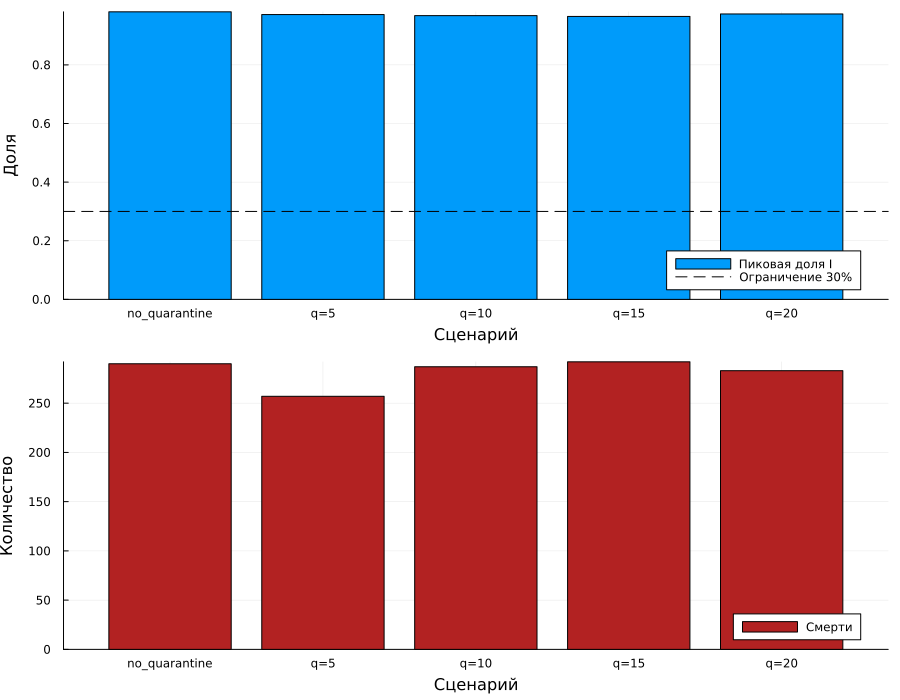

In [2]:
summary_df, dynamics = quarantine_experiment()
summary_df

summary_plot = plot_quarantine_summary(summary_df)
summary_plot

## Сравнение лучшего карантинного режима с базовым

Из всех карантинных сценариев выбирается режим с минимальным числом смертей.

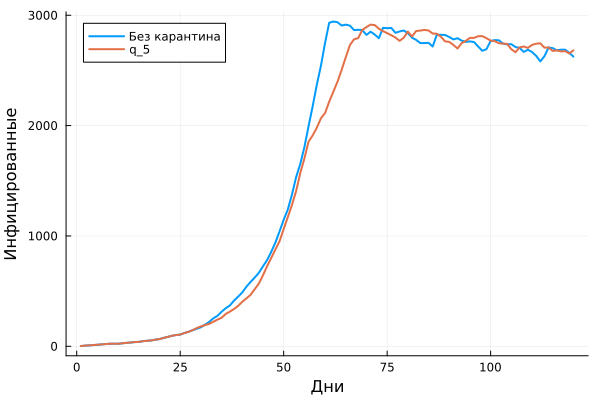

In [3]:
candidate_df = filter(row -> row.scenario != "no_quarantine" && row.locked_cities > 0, summary_df)
best_label = if nrow(candidate_df) == 0
    "no_quarantine"
else
    candidate_df[argmin(candidate_df.deaths), :scenario]
end

baseline_df = dynamics["no_quarantine"].global_df
best_df = dynamics[best_label].global_df
dynamics_plot = plot_quarantine_dynamics(baseline_df, best_df; quarantine_label = best_label)
dynamics_plot

## Выводы

1. Закрытие города уменьшает исходящую миграцию и замедляет распространение.
2. Разные пороги дают разный компромисс между скоростью пика и смертностью.
3. В проверенной серии лучший эффект дал самый ранний из рассмотренных порогов.